In [1]:
"""plot average sign and loss as heatmap."""
import numpy as np  # noqa
# import os  # noqa
# import matplotlib.gridspec as gridspec  # noqa
import matplotlib.pyplot as plt  # noqa
import pandas as pd  # noqa
import itertools  # noqa
from mpl_toolkits.axes_grid1 import make_axes_locatable
# import pandas  # noqa

import sys  # noqa
from pathlib import Path  # noqa
PYTHON_DIR = Path("/home/keisuke/worms/python" )
sys.path.insert(0, PYTHON_DIR.resolve().as_posix())
print(sys.path)
from rmsKit import utils  # noqa
logger = utils.get_logger("log.log", level="INFO", stdout=True)

IMAGE_PATH = PYTHON_DIR / "visualize" / "image"
WORM_RESULT_PATH = PYTHON_DIR / "rmsKit" / "array" / "torch"

model_name = "BLBQ1D"
image_model_dir = IMAGE_PATH / model_name
worm_result_path = WORM_RESULT_PATH / (model_name+"_loc")

N = 10**7
BETA_THRES = 20

if not IMAGE_PATH.exists():
    raise FileNotFoundError("{} does not exist.".format(IMAGE_PATH.resolve()))
if not WORM_RESULT_PATH.exists():
    raise FileNotFoundError("{} does not exist.".format(WORM_RESULT_PATH.resolve()))
if not worm_result_path.exists():
    raise FileNotFoundError("{} does not exist.".format(worm_result_path.resolve()))

summary_files = utils.path.find_summary_files(worm_result_path)
df = utils.path.get_df_from_summary_files(summary_files, N)


['/home/keisuke/worms/python', '/opt/materiapps/intel/boost/boost-1.82.0-1/lib/python', '/opt/intel/oneapi/advisor/2024.2/pythonapi', '/home/keisuke/miniconda3/envs/py311/lib/python311.zip', '/home/keisuke/miniconda3/envs/py311/lib/python3.11', '/home/keisuke/miniconda3/envs/py311/lib/python3.11/lib-dynload', '', '/home/keisuke/.local/lib/python3.11/site-packages', '/home/keisuke/miniconda3/envs/py311/lib/python3.11/site-packages']
06.03 18:01 -- INFO   Log file will be saved to log.log


In [2]:
params_df = utils.param_dict_normalize(df['ham_path'].apply(utils.extract_parameters_from_path))
df = pd.concat([df, params_df], axis=1)

In [4]:
# Get unique pairs of J2 and J3 values
unique_pairs = df[['J1', 'hx']].drop_duplicates().sort_values(['J1', 'hx'])
print("Unique J2, J3 pairs:")
print(unique_pairs)

Unique J2, J3 pairs:
      J1   hx
0    0.5  0.0
112  1.0  0.5


Text(0, 0.5, 'Specific Heat')

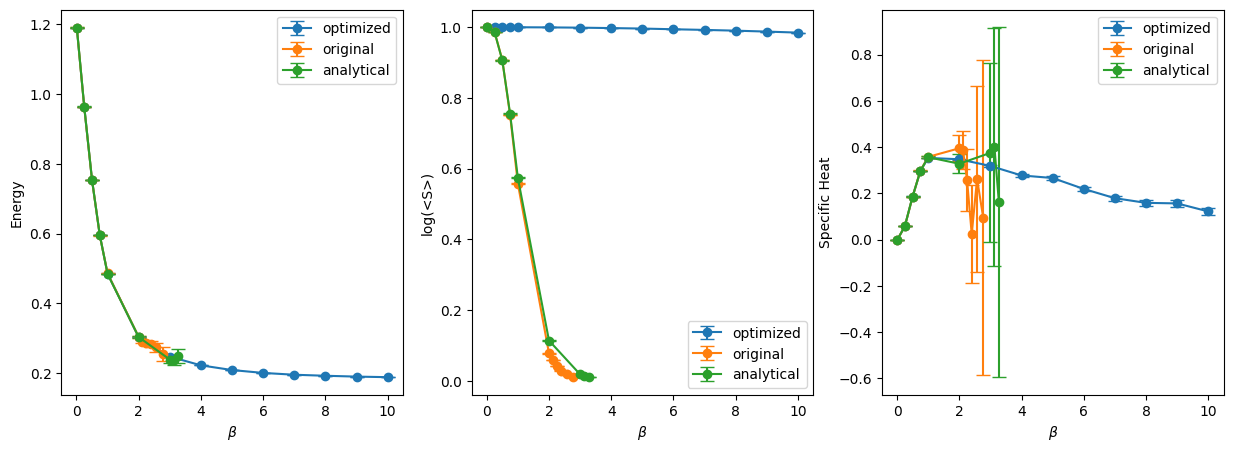

In [5]:
J1 = 1.0
hx = 0.5

_df = df[(df.J1 == J1) & (df.hx == hx)]

dict_df = {
    "optimized": _df[(_df.u_path.notna()) & (_df.loss_func == "1_mel")].drop_duplicates(subset=['T']),
    "original": _df[(_df.u_path.isna()) & (_df.loss_func == "1_mel")].drop_duplicates(subset=['T']),
    "analytical": _df[(_df.u_path.isna()) & (_df.loss_func == "-1_none")].drop_duplicates(subset=['T']),
}


for key, df_t in dict_df.items():
    mask = (df_t['as'] > 0.01) & (df_t['T'] >= 0.1)
    df_t = df_t[mask]
    # sort by T
    df_t = df_t.sort_values(by='T')
    dict_df[key] = df_t

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))  

label = f"J1={J1}, hx={hx}"

for key, df_t in dict_df.items():
    # Plot with error bars
    ax1.errorbar(1/df_t["T"], df_t["e"], yerr=df_t["e_error"], 
                fmt='o-', capsize=5, label=key)
    ax2.errorbar(1/df_t["T"], df_t["as"], yerr=df_t["as_error"],
                fmt='o-', capsize=5, label=key)
    ax3.errorbar(1/df_t["T"], df_t["c"], yerr=df_t["c_error"],
                fmt='o-', capsize=5, label=key)

ax1.legend()
ax1.set_xlabel("$\\beta$")
ax1.set_ylabel("Energy")

ax2.legend()
ax2.set_xlabel("$\\beta$")
ax2.set_ylabel("log(<S>)")

ax3.legend()
ax3.set_xlabel("$\\beta$")
ax3.set_ylabel("Specific Heat")


,model_name,alpha,T,bc,n_sites,u_path,ham_path,sweeps,as,as_error,...,m_error,chi,chi_error,loss_func,init_loss,loss,J0,J1,hx,hz
114,BLBQ1D,0.2,1.0,obc,10,NaN,/home/keisuke/worms/python/rmsKit/array/torch/...,10000000,0.573653,0.001301,...,0.0,0.0,0.0,-1_none,0.000000,NaN,1.0,1.0,0.5,0.0
115,BLBQ1D,0.2,1.0,obc,3,NaN,/home/keisuke/worms/python/rmsKit/array/torch/...,10000000,0.932913,0.000594,...,0.0,0.0,0.0,-1_none,0.000000,NaN,1.0,1.0,0.5,0.0
119,BLBQ1D,0.2,1.0,obc,10,NaN,/home/keisuke/worms/python/rmsKit/array/torch/...,10000000,0.574123,0.001276,...,0.0,0.0,0.0,-1_none,0.000000,NaN,1.0,1.0,0.5,0.0
127,BLBQ1D,0.2,1.0,obc,2,NaN,/home/keisuke/worms/python/rmsKit/array/torch/...,10000000,0.980418,0.000364,...,0.0,0.0,0.0,-1_none,0.000000,NaN,1.0,1.0,0.5,0.0
128,BLBQ1D,0.2,1.0,obc,4,NaN,/home/keisuke/worms/python/rmsKit/array/torch/...,10000000,0.873704,0.000823,...,0.0,0.0,0.0,-1_none,0.000000,NaN,1.0,1.0,0.5,0.0
129,BLBQ1D,0.2,1.0,obc,8,NaN,/home/keisuke/worms/python/rmsKit/array/torch/...,10000000,0.662065,0.001195,...,0.0,0.0,0.0,-1_none,0.000000,NaN,1.0,1.0,0.5,0.0
130,BLBQ1D,0.2,1.0,obc,16,NaN,/home/keisuke/worms/python/rmsKit/array/torch/...,10000000,0.376572,0.001467,...,0.0,0.0,0.0,-1_none,0.000000,NaN,1.0,1.0,0.5,0.0
131,BLBQ1D,0.2,1.0,obc,32,NaN,/home/keisuke/worms/python/rmsKit/array/torch/...,10000000,0.123060,0.001199,...,0.0,0.0,0.0,-1_none,0.000000,NaN,1.0,1.0,0.5,0.0
132,BLBQ1D,0.2,1.0,obc,64,NaN,/home/keisuke/worms/python/rmsKit/array/torch/...,10000000,0.015024,0.000945,...,0.0,0.0,0.0,-1_none,0.000000,NaN,1.0,1.0,0.5,0.0
133,BLBQ1D,0.2,1.0,obc,128,NaN,/home/keisuke/worms/python/rmsKit/array/torch/...,10000000,-0.000237,0.000778,...,0.0,0.0,0.0,-1_none,0.000000,NaN,1.0,1.0,0.5,0.0


Text(0, 0.5, 'Specific Heat')

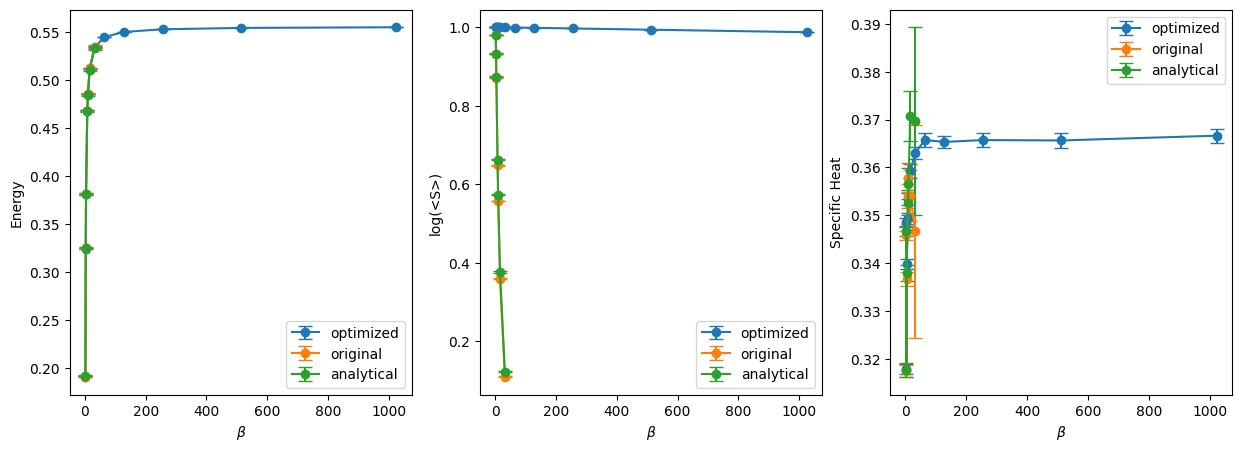

In [17]:
J1 = 1.0
hx = 0.5

_df = df[(df.J1 == J1) & (df.hx == hx) & (df["T"] == 1.0)]

dict_df = {
    "optimized": _df[(_df.u_path.notna()) & (_df.loss_func == "1_mel")].drop_duplicates(subset=['n_sites']),
    "original": _df[(_df.u_path.isna()) & (_df.loss_func == "1_mel")].drop_duplicates(subset=['n_sites']),
    "analytical": _df[(_df.u_path.isna()) & (_df.loss_func == "-1_none")].drop_duplicates(subset=['n_sites']),
}


for key, df_t in dict_df.items():
    mask = (df_t['as'] > 0.02) & (df_t['T'] >= 0.1)
    df_t = df_t[mask]
    # sort by T
    df_t = df_t.sort_values(by='n_sites')
    dict_df[key] = df_t

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))  

label = f"J1={J1}, hx={hx}"

for key, df_t in dict_df.items():
    # Plot with error bars
    ax1.errorbar(df_t["n_sites"], df_t["e"], yerr=df_t["e_error"], 
                fmt='o-', capsize=5, label=key)
    ax2.errorbar(df_t["n_sites"], df_t["as"], yerr=df_t["as_error"],
                fmt='o-', capsize=5, label=key)
    ax3.errorbar(df_t["n_sites"], df_t["c"], yerr=df_t["c_error"],
                fmt='o-', capsize=5, label=key)

ax1.legend()
ax1.set_xlabel("$\\beta$")
ax1.set_ylabel("Energy")

ax2.legend()
ax2.set_xlabel("$\\beta$")
ax2.set_ylabel("log(<S>)")

ax3.legend()
ax3.set_xlabel("$\\beta$")
ax3.set_ylabel("Specific Heat")
